<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/main/project_jenny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [ ]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jennifershearer","key":"5529e94eaf186ebe27882dd6438bf917"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 700M/700M [00:44<00:00, 16.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/1


In [ ]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd


In [ ]:
dataset_path = path + "/data"
output_path = path + "/dataset_split"

valid_ext = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

# Step 1: collect all images + labels
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    if not os.path.isdir(label_path):
        continue

    for f in os.listdir(label_path):
        if f.lower().endswith(valid_ext):
            full_path = os.path.join(label_path, f)
            image_paths.append(full_path)
            labels.append(label)

# Step 2: split (reproducible)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Step 3: function to copy into structured folders
def copy_to_split(paths, labels, split_name):
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(output_path, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)

        filename = os.path.basename(src_path)
        dest_path = os.path.join(dest_dir, filename)

        shutil.copy2(src_path, dest_path)

# Step 4: create splits
copy_to_split(train_paths, train_labels, "train")
copy_to_split(test_paths, test_labels, "test")

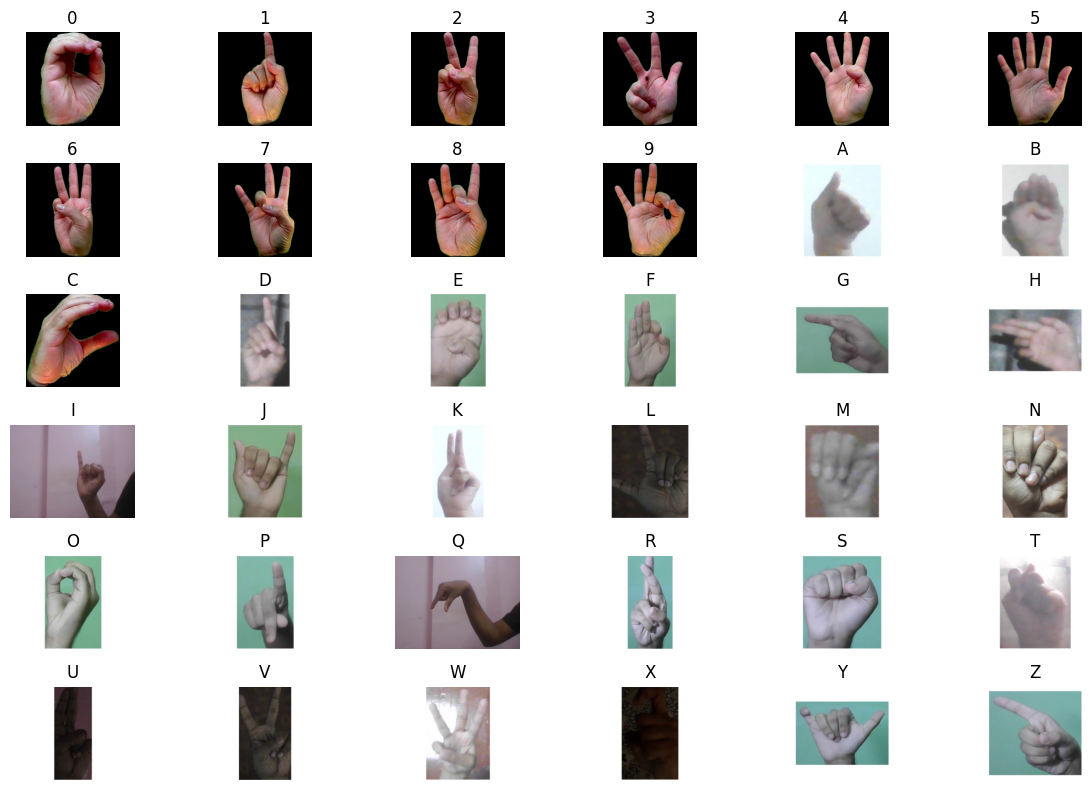

In [ ]:
train_path = path + "/dataset_split/train"  # path to your train split
labels = sorted(os.listdir(train_path))      # list of label folders

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    label_path = os.path.join(train_path, label)

    if not os.path.isdir(label_path):
        continue

    # get all image files in this label folder
    valid_ext = (".jpg", ".jpeg", ".png")
    images = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(valid_ext) and os.path.isfile(os.path.join(label_path, f))
    ]

    if len(images) == 0:
        continue

    # pick one random image
    img_name = random.choice(images)
    img_path = os.path.join(label_path, img_name)
    img = Image.open(img_path)

    plt.subplot(6, 6, i + 1)  # adjust grid depending on #labels
    plt.imshow(img)
    plt.title(label.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

load the base of MobileNetV2

In [ ]:
BaseModel = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

Find what layers we should exit from:

In [ ]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_relu


The expabded relu is where we want to make the early exits, before it is projected

In [ ]:
Exit1 = BaseModel.get_layer("block_3_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

def ExitHead(x, NumClasses):
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  return layers.Dense(NumClasses, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, 10)
Exit2Output = ExitHead(Exit2, 10)


x = BaseModel.output
x = layers.GlobalAveragePooling2D()(x)
FinalOutput = layers.Dense(10, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])


In [ ]:
import tensorflow as tf

# Get the number of classes from the `labels` variable available in the kernel state
# The 'labels' variable contains 36 unique classes (0-9, a-z)
num_classes = len(labels)
print(f"Detected {num_classes} classes for training.")

# Define train_ds and test_ds using image_dataset_from_directory
# Set label_mode='categorical' for one-hot encoding as categorical_crossentropy is used
train_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)


train_ds = train_ds.map(lambda x, y: (x, (y, y, y)))
test_ds = test_ds.map(lambda x, y: (x, (y, y, y)))


# Redefine the ExitHead function and the model with the correct number of classes
# Assuming BaseModel, layers, and Model are already defined from previous cells
Exit1 = BaseModel.get_layer("block_3_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

def ExitHead(x, num_classes_arg):
  x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  return layers.Dense(num_classes_arg, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, num_classes)
Exit2Output = ExitHead(Exit2, num_classes)

x = BaseModel.output
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
FinalOutput = layers.Dense(num_classes, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])

# Compile the model
NewModel.compile(
    optimizer='adam',
    loss=['categorical_crossentropy'] * 3,
    loss_weights = [0.5, 0.5, 1.0],
    metrics=['accuracy'] * 3) # Fixed: metrics should be a list of 3 for 3 outputs

# Fit the model
print("\nStarting model training...")
NewModel.fit(
    train_ds,
    validation_data = test_ds,
    epochs = 10,
)

Detected 36 classes for training.
Found 35260 files belonging to 36 classes.
Found 8815 files belonging to 36 classes.

Starting model training...
Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 256s 179ms/step - dense_26_accuracy: 0.3088 - dense_26_loss: 2.2180 - dense_28_accuracy: 0.7412 - dense_28_loss: 0.8610 - dense_30_accuracy: 0.8541 - dense_30_loss: 0.5439 - loss: 2.0835 - val_dense_26_accuracy: 0.0397 - val_dense_26_loss: 26.8512 - val_dense_28_accuracy: 0.2399 - val_dense_28_loss: 6.4552 - val_dense_30_accuracy: 0.2095 - val_dense_30_loss: 6.9404 - val_loss: 23.5900
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 158s 143ms/step - dense_26_accuracy: 0.5480 - dense_26_loss: 1.3758 - dense_28_accuracy: 0.9446 - dense_28_loss: 0.1816 - dense_30_accuracy: 0.9591 - dense_30_loss: 0.1504 - loss: 0.9291 - val_dense_26_accuracy: 0.1046 - val_dense_26_loss: 5.8654 - val_dense_28_accuracy: 0.3701 - val_dense_28_loss: 4.0554 - val_dense_30_accuracy: 0.4048 - val_dense_30_loss: 2.9794 - val_loss: 7.

In [ ]:
results = NewModel.evaluate(test_ds, verbose=0)
metric_names = NewModel.metrics_names

# zip ensures matching length
df = pd.DataFrame(list(zip(metric_names, results)),
                  columns=["Metric", "Value"])

print(df.to_string(index=False))

         Metric    Value
           loss 3.057743
compile_metrics 5.811192
  dense_26_loss 0.114411
  dense_28_loss 0.097291
  dense_30_loss 0.282019


In [ ]:
for images, labels_one_hot in test_ds.take(1):
    break

**Reasoning**:
Now that I have a batch of images, I will use the trained `NewModel` to make predictions on these images. Since the model has multiple outputs, the prediction will return a list of predicted probabilities for each exit head.



In [ ]:
predictions = NewModel.predict(images)
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
exit_names = ["Exit 1 (early exit)", "Exit 2 (intermediate exit)", "Final Output"]

for i, pred in enumerate(predictions):
    y_pred = np.argmax(pred, axis=1)
    accuracy = np.mean(y_pred == true_labels)
    print(f"Overall accuracy for {exit_names[i]}: {accuracy*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Overall accuracy for Exit 1 (early exit): 31.25%
Overall accuracy for Exit 2 (intermediate exit): 84.38%
Overall accuracy for Final Output: 96.88%


Output:0


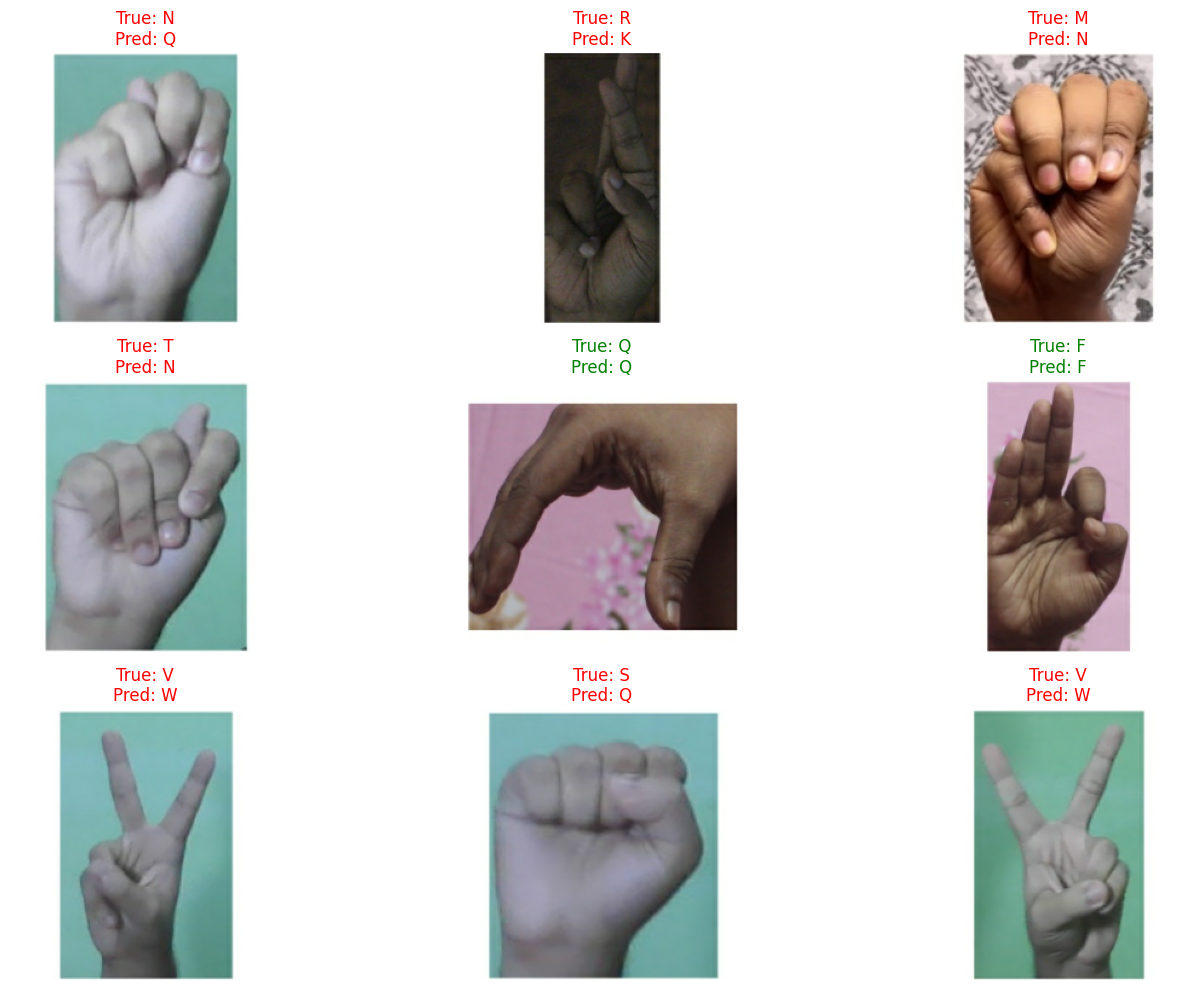

Output:1


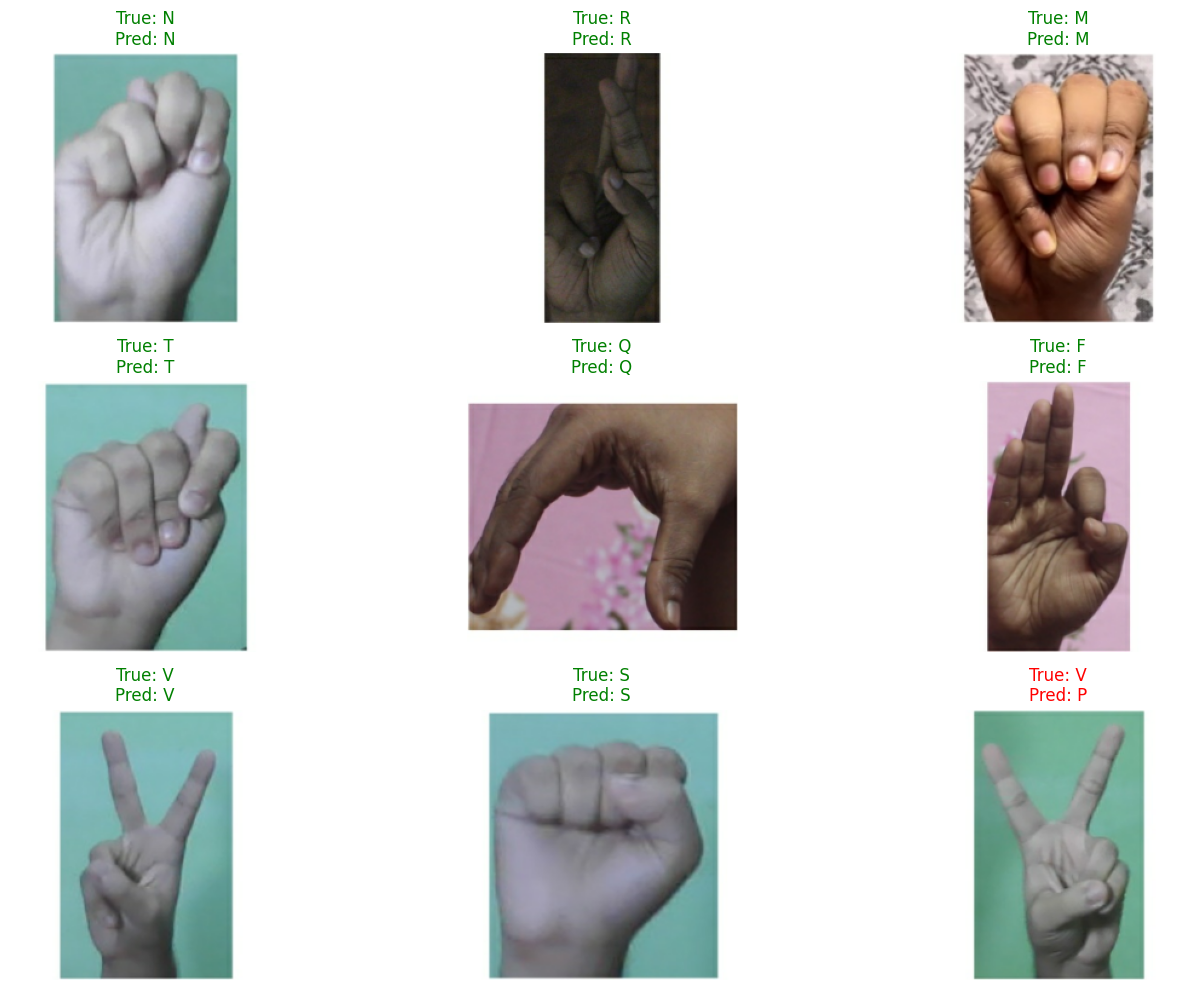

Output:2


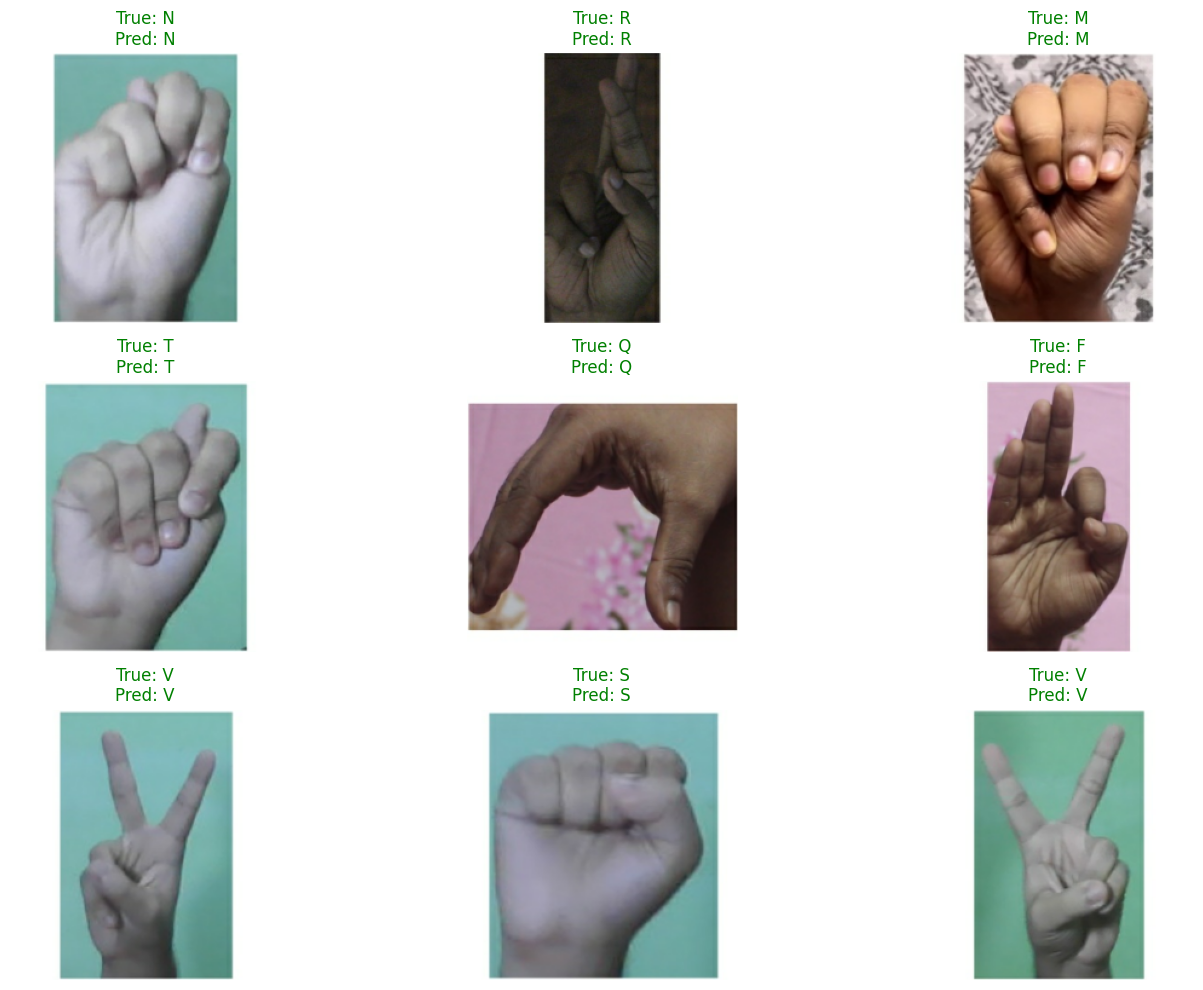

In [ ]:
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
for j in range(3):
  print(f"Output:{j}")
  predicted_labels = tf.argmax(predictions[j], axis=1).numpy()

  plt.figure(figsize=(15, 10))
  for i in range(min(len(images), 9)):
      plt.subplot(3, 3, i + 1)
      plt.imshow(images[i].numpy().astype("uint8"))

      true_class_name = labels[true_labels[i]]
      predicted_class_name = labels[predicted_labels[i]]

      color = "green" if true_class_name == predicted_class_name else "red"
      plt.title(f"True: {true_class_name.upper()}\nPred: {predicted_class_name.upper()}", color=color)
      plt.axis("off")

  plt.tight_layout()
  plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [99]:
LoadedModel = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model.keras")

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: collect predictions for final exit
y_pred0_list = []
y_pred1_list = []
y_pred2_list = []
j=0

for x_batch, y_batch in test_ds:
  j+=1
  # pick the final exit (third)
  preds = LoadedModel.predict(x_batch, verbose=0)  # final output
  preds0_classes = np.argmax(preds[0], axis=1)
  preds1_classes = np.argmax(preds[1], axis=1)
  preds2_classes = np.argmax(preds[2], axis=1)
  y_true = tf.argmax(y_batch[0], axis=1).numpy()
  y_pred0_list.extend(preds0_classes)
  y_pred1_list.extend(preds1_classes)
  y_pred2_list.extend(preds2_classes)
  if j==40:
    break

y_preds = [np.array(y_pred0_list), np.array(y_pred1_list), np.array(y_pred2_list)]
y_true = np.array(y_true)


In [ ]:

for y_pred in y_preds:
  cm = confusion_matrix(y_true, y_pred)
  # Use your class labels (folder names)
  class_labels = sorted(os.listdir(output_path + "/train"))

  plt.figure(figsize=(12,10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=class_labels,
              yticklabels=class_labels)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix - Final Exit")
  plt.show()

### Summary of Model Performance

**Evaluation Metrics:**
The model was evaluated on the `test_ds` and yielded the following results:
- **Total Loss:** 13.494
- **Exit 1 (Early Exit) Loss:** 6.528
- **Exit 2 (Intermediate Exit) Loss:** 10.968
- **Final Output Loss:** 4.747
- **Exit 1 (Early Exit) Accuracy:** 5.33%
- **Exit 2 (Intermediate Exit) Accuracy:** 8.88%
- **Final Output Accuracy:** 44.38%

From these metrics, it's clear that the model's performance is not optimal. The accuracy for all exits, especially the early and intermediate exits, is very low. The final output's accuracy of 44.38% suggests that while it performs better than the early exits, there is still significant room for improvement.

**Visualized Predictions:**
The visualizations show that the model often misclassifies images. Many of the sample images display a red title, indicating that the `Predicted` label does not match the `True` label. This aligns with the low accuracy scores observed in the evaluation metrics.

**Overall Conclusion:**
The current model, after only 2 epochs of training, is underperforming for this classification task. The low accuracies across all exit points, coupled with the visual evidence of misclassifications, indicate that further training (more epochs), hyperparameter tuning, or architectural adjustments are necessary to achieve better results.

## Summary:

### Data Analysis Key Findings

*   **Overall Performance:** The `NewModel` exhibited poor performance, particularly for the early and intermediate exits.
*   **Evaluation Metrics:**
    *   **Total Loss:** 13.494
    *   **Exit 1 (Early Exit) Loss:** 6.528, with an accuracy of 5.33%.
    *   **Exit 2 (Intermediate Exit) Loss:** 10.968, with an accuracy of 8.88%.
    *   **Final Output Loss:** 4.747, with an accuracy of 44.38%.
*   **Prediction Discrepancy:** Visualized predictions showed frequent misclassifications, as indicated by red titles for many sample images where the predicted label did not match the true label.

### Insights or Next Steps

*   The current model, after only 2 epochs of training, is underperforming and requires significant improvement to be effective.
*   Further optimization is necessary, including extended training (more epochs), hyperparameter tuning, or potential architectural adjustments, to enhance its classification capabilities.
